# Analysis ONNX

## Setup

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

with open("../results/metrics/onnx_runtime.json") as f:
    onnx = json.load(f)

with open("../results/metrics/float16.json") as f:
    baseline = json.load(f)

# Summary
labels   = ["float16 (PyTorch)", "ONNX Runtime"]
colors   = ["#3498db", "#e67e22"]

metrics = {
    "ttft_p50_ms":    [baseline["ttft_p50_ms"],    onnx["ttft_p50_ms"]],
    "itl_p50_ms":     [baseline["itl_p50_ms"],     onnx["itl_p50_ms"]],
    "itl_p99_ms":     [baseline["itl_p99_ms"],     onnx["itl_p99_ms"]],
    "throughput_tps": [baseline["throughput_tps"], onnx["throughput_tps"]],
    "peak_memory_mb": [baseline["peak_memory_mb"], onnx["peak_memory_mb"]],
    "perplexity":     [baseline["perplexity"],     onnx["perplexity"]],
}

print("Metric comparison:")
print(f"{'metric':>20} {'float16':>12} {'onnx':>12} {'diff':>10}")
for metric, vals in metrics.items():
    diff = (vals[1] - vals[0]) / vals[0] * 100
    direction = "↑ worse" if metric in ["ttft_p50_ms", "itl_p50_ms",
                                         "itl_p99_ms", "peak_memory_mb",
                                         "perplexity"] and diff > 0 \
                else "↓ better" if diff < 0 else "↑ worse"
    print(f"{metric:>20} {vals[0]:>12.2f} {vals[1]:>12.2f} "
          f"{diff:>+9.1f}% {direction}")

Metric comparison:
              metric      float16         onnx       diff
         ttft_p50_ms        44.49        68.04     +53.0% ↑ worse
          itl_p50_ms        35.25        33.60      -4.7% ↓ better
          itl_p99_ms        63.43        96.05     +51.4% ↑ worse
      throughput_tps        25.58        22.72     -11.2% ↓ better
      peak_memory_mb      3588.99      2774.33     -22.7% ↓ better
          perplexity         7.82         7.82      -0.0% ↓ better


## Side by Side Metrics Comparison

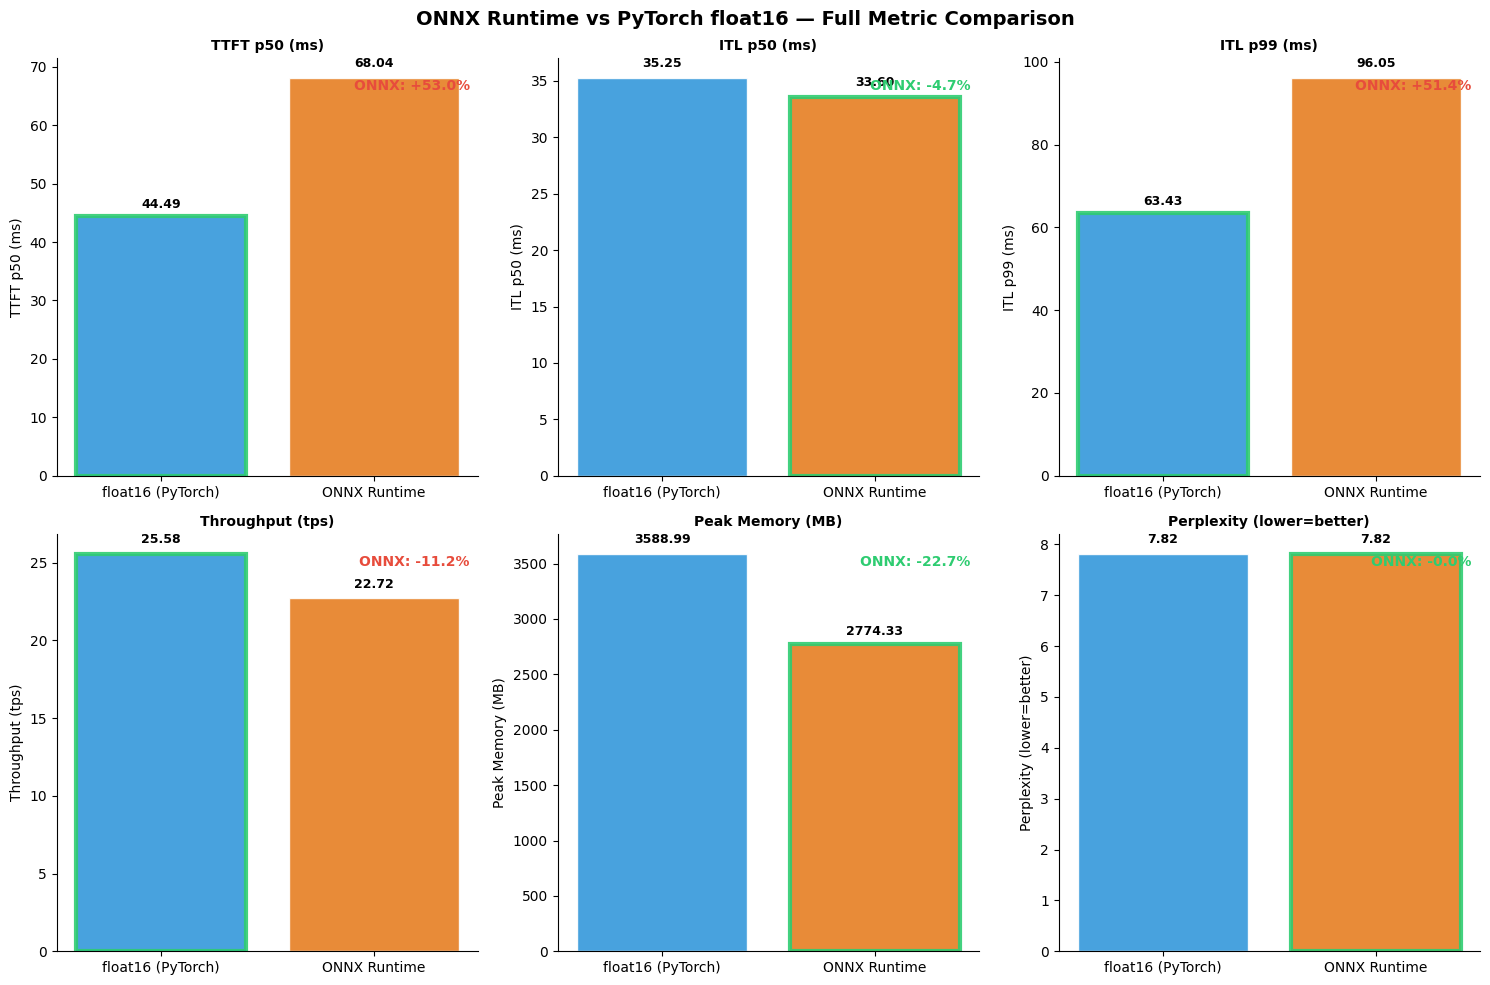

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("ONNX Runtime vs PyTorch float16 — Full Metric Comparison",
             fontsize=14, fontweight="bold")

metric_configs = [
    ("ttft_p50_ms",    "TTFT p50 (ms)",         True,  axes[0, 0]),
    ("itl_p50_ms",     "ITL p50 (ms)",           True,  axes[0, 1]),
    ("itl_p99_ms",     "ITL p99 (ms)",           True,  axes[0, 2]),
    ("throughput_tps", "Throughput (tps)",        False, axes[1, 0]),
    ("peak_memory_mb", "Peak Memory (MB)",        True,  axes[1, 1]),
    ("perplexity",     "Perplexity (lower=better)", True, axes[1, 2]),
]

for metric, ylabel, lower_better, ax in metric_configs:
    vals  = metrics[metric]
    bars  = ax.bar(labels, vals, color=colors,
                   edgecolor="white", alpha=0.9)

    # Highlight winner
    winner_idx = np.argmin(vals) if lower_better else np.argmax(vals)
    bars[winner_idx].set_edgecolor("#2ecc71")
    bars[winner_idx].set_linewidth(3)

    # Annotate values
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + bar.get_height() * 0.02,
                f"{val:.2f}", ha="center", va="bottom",
                fontsize=9, fontweight="bold")

    # Delta annotation
    delta = (vals[1] - vals[0]) / vals[0] * 100
    color = "#2ecc71" if (lower_better and delta < 0) or \
                         (not lower_better and delta > 0) else "#e74c3c"
    ax.text(0.98, 0.95, f"ONNX: {delta:+.1f}%",
            transform=ax.transAxes, ha="right", va="top",
            fontsize=10, color=color, fontweight="bold")

    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(ylabel, fontsize=10, fontweight="bold")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
Path("../results/figures/onnx").mkdir(parents=True, exist_ok=True)
plt.savefig("../results/figures/onnx/metrics_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()

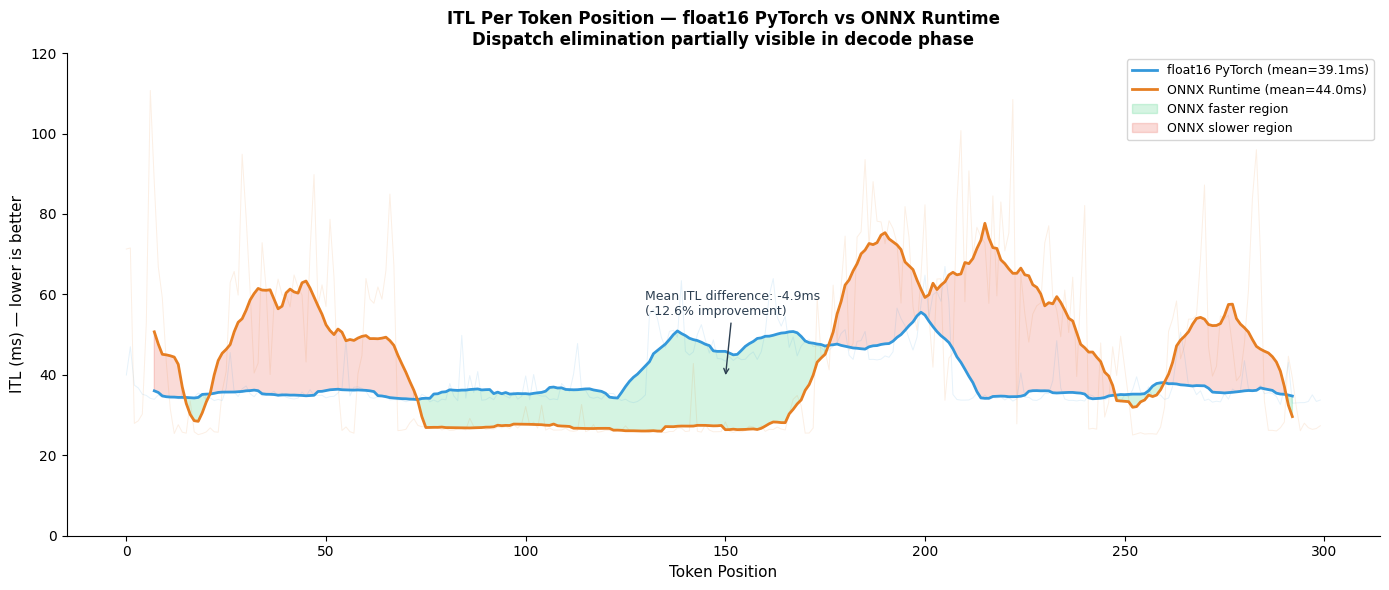

ITL statistics:
  float16: mean=39.1ms, std=7.3ms
  onnx:    mean=44.0ms, std=20.5ms
  improvement: -4.9ms (-12.6%)


In [4]:
fig, ax = plt.subplots(figsize=(14, 6))

itl_onnx     = np.array(onnx["itl_per_position"])
itl_baseline = np.array(baseline["itl_per_position"])

# Truncate ke panjang yang sama
min_len      = min(len(itl_onnx), len(itl_baseline))
itl_onnx     = itl_onnx[:min_len]
itl_baseline = itl_baseline[:min_len]
positions    = np.arange(min_len)
window       = 15

smooth_onnx     = np.convolve(itl_onnx,     np.ones(window)/window, mode='valid')
smooth_baseline = np.convolve(itl_baseline, np.ones(window)/window, mode='valid')
smooth_pos      = np.arange(len(smooth_onnx)) + window//2

# Raw signal faint
ax.plot(positions, itl_baseline,
        color="#3498db", alpha=0.12, linewidth=0.7)
ax.plot(positions, itl_onnx,
        color="#e67e22", alpha=0.12, linewidth=0.7)

# Smoothed signal solid
ax.plot(smooth_pos, smooth_baseline,
        color="#3498db", linewidth=2,
        label=f"float16 PyTorch (mean={itl_baseline.mean():.1f}ms)")
ax.plot(smooth_pos, smooth_onnx,
        color="#e67e22", linewidth=2,
        label=f"ONNX Runtime (mean={itl_onnx.mean():.1f}ms)")

# Fill between
ax.fill_between(smooth_pos, smooth_baseline, smooth_onnx,
                where=smooth_onnx < smooth_baseline,
                alpha=0.2, color="#2ecc71",
                label="ONNX faster region")
ax.fill_between(smooth_pos, smooth_baseline, smooth_onnx,
                where=smooth_onnx >= smooth_baseline,
                alpha=0.2, color="#e74c3c",
                label="ONNX slower region")

# Annotate mean difference
mean_diff = itl_baseline.mean() - itl_onnx.mean()
ax.annotate(f"Mean ITL difference: {mean_diff:.1f}ms\n"
            f"({mean_diff/itl_baseline.mean()*100:.1f}% improvement)",
            xy=(min_len//2, min(smooth_onnx.mean(), smooth_baseline.mean())),
            xytext=(min_len//2 - 20, 55),
            fontsize=9, color="#2c3e50",
            arrowprops=dict(arrowstyle="->", color="#2c3e50"))

ax.set_xlabel("Token Position", fontsize=11)
ax.set_ylabel("ITL (ms) — lower is better", fontsize=11)
ax.set_title("ITL Per Token Position — float16 PyTorch vs ONNX Runtime\n"
             "Dispatch elimination partially visible in decode phase",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(0, 120)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../results/figures/onnx/itl_per_position_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"ITL statistics:")
print(f"  float16: mean={itl_baseline.mean():.1f}ms, "
      f"std={itl_baseline.std():.1f}ms")
print(f"  onnx:    mean={itl_onnx.mean():.1f}ms, "
      f"std={itl_onnx.std():.1f}ms")
print(f"  improvement: {mean_diff:.1f}ms "
      f"({mean_diff/itl_baseline.mean()*100:.1f}%)")

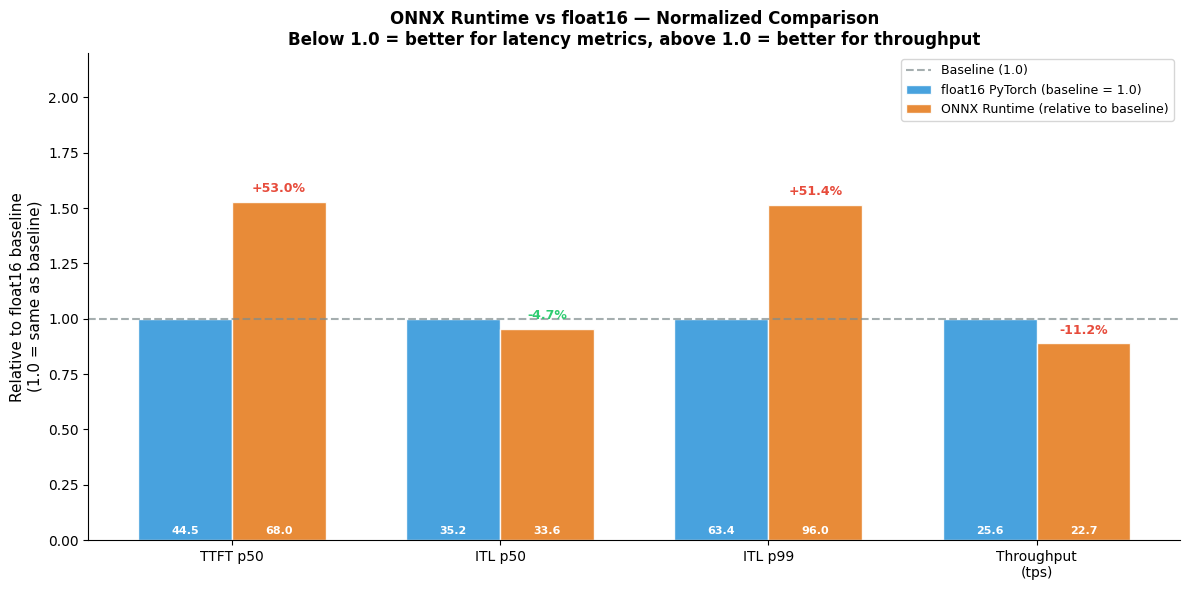


ONNX vs float16 relative performance:
  TTFT p50       : baseline=44.5, onnx=68.0, delta=+53.0%
  ITL p50        : baseline=35.2, onnx=33.6, delta=-4.7%
  ITL p99        : baseline=63.4, onnx=96.0, delta=+51.4%
  Throughput
(tps): baseline=25.6, onnx=22.7, delta=-11.2%


In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

metric_labels = ["TTFT p50", "ITL p50", "ITL p99", "Throughput\n(tps)"]

baseline_vals = [
    baseline["ttft_p50_ms"],
    baseline["itl_p50_ms"],
    baseline["itl_p99_ms"],
    baseline["throughput_tps"],
]
onnx_vals = [
    onnx["ttft_p50_ms"],
    onnx["itl_p50_ms"],
    onnx["itl_p99_ms"],
    onnx["throughput_tps"],
]

baseline_norm = [1.0] * len(baseline_vals)
onnx_norm     = [o / b for o, b in zip(onnx_vals, baseline_vals)]

x     = np.arange(len(metric_labels))
width = 0.35

bars1 = ax.bar(x - width/2, baseline_norm, width,
               label="float16 PyTorch (baseline = 1.0)",
               color="#3498db", edgecolor="white", alpha=0.9)

bars2 = ax.bar(x + width/2, onnx_norm, width,
               label="ONNX Runtime (relative to baseline)",
               color="#e67e22", edgecolor="white", alpha=0.9)

ax.axhline(y=1.0, color="#7f8c8d", linestyle="--",
           linewidth=1.5, alpha=0.7, label="Baseline (1.0)")

lower_better_idx = [0, 1, 2]  
higher_better_idx = [3]        

for i, (norm, actual_b, actual_o) in enumerate(zip(
        onnx_norm, baseline_vals, onnx_vals)):
    is_better = (norm < 1.0 and i in lower_better_idx) or \
                (norm > 1.0 and i in higher_better_idx)
    color = "#2ecc71" if is_better else "#e74c3c"
    delta = (actual_o - actual_b) / actual_b * 100

    ax.text(x[i] + width/2,
            norm + 0.03,
            f"{delta:+.1f}%",
            ha="center", va="bottom",
            fontsize=9, fontweight="bold", color=color)

    # Actual values di bawah bar
    ax.text(x[i] + width/2, 0.02,
            f"{actual_o:.1f}",
            ha="center", va="bottom",
            fontsize=8, color="white", fontweight="bold")

    ax.text(x[i] - width/2, 0.02,
            f"{actual_b:.1f}",
            ha="center", va="bottom",
            fontsize=8, color="white", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=10)
ax.set_ylabel("Relative to float16 baseline\n(1.0 = same as baseline)",
              fontsize=11)
ax.set_title("ONNX Runtime vs float16 — Normalized Comparison\n"
             "Below 1.0 = better for latency metrics, "
             "above 1.0 = better for throughput",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(0, 2.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("../results/figures/onnx/dispatch_overhead_breakdown.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("\nONNX vs float16 relative performance:")
lower_better = ["ttft_p50_ms", "itl_p50_ms", "itl_p99_ms"]
for label, b, o in zip(metric_labels, baseline_vals, onnx_vals):
    delta = (o - b) / b * 100
    print(f"  {label:15s}: baseline={b:.1f}, onnx={o:.1f}, "
          f"delta={delta:+.1f}%")